In [1]:
import marimo as mo
import sys, os

import MGKDB_parameter_overview.src.query_parameters as qp

## MGKDB Parameter Sparsity Scan

In [2]:
lookup = qp.load_lookup(qp.LOOKUP_FILE)
print(f"Loaded {len(lookup)} queryable parameters:")
for e in lookup:
    print(f"  {e['parameter_name']:30s}  {e['db_field']}")

Loaded 18 queryable parameters:
  Beta                            gyrokinetics.species_all.beta_reference
  q                               gyrokinetics.flux_surface.q
  collisionality_elec             gyrokinetics.collisions.collisionality_norm[e][e]
  collisionality_ions             gyrokinetics.collisions.collisionality_norm[i][i]
  s-hat                           gyrokinetics.flux_surface.magnetic_shear_r_minor
  temp_grad_elec                  gyrokinetics.species[e].temperature_log_gradient_norm
  temp_grad_ion                   gyrokinetics.species[i].temperature_log_gradient_norm
  dens_grad_elec                  gyrokinetics.species[e].density_log_gradient_norm
  dens_grad_ion                   gyrokinetics.species[i].density_log_gradient_norm
  impurity_density                gyrokinetics.species[z].density_norm
  impurity_charge                 gyrokinetics.species[z].charge_norm
  Zeff                            gyrokinetics.species_all.zeff
  triangularity                 

In [3]:
from TPED.config.config_helper import Config
from mgkdb.support.mgk_login import f_login_dbase

config = Config()
auth = config.get_path('MGKDB_AUTH_PKL')
login = f_login_dbase(auth)
client, database = login.connect()
print("Connected to DB:", database.name)

Connected to DB: mgk_fusion


In [4]:
import pandas as pd

projection = {'gyrokineticsIMAS': 1, 'gyrokinetics': 1, 'Metadata.CodeTag': 1}
rows = []
nan_debug = {}  # create once outside the loop

for col_name in qp.COLLECTIONS:
    collection = database[col_name]
    print(f"{col_name}: {collection.count_documents({})} records")
    for record in collection.find({}, projection):
        row = qp.extract_params(record, lookup, nan_debug=nan_debug)  # same dict reused
        row['collection'] = col_name
        rows.append(row)

df = pd.DataFrame(rows)
print(f"\nTotal records: {len(df)}")

# NaN debug summary
if nan_debug:
    total = sum(nan_debug.values())
    print(f'\n[NaN debug summary] {total} NaN hits across all parameters and paths:')
    by_param = {}
    for (param, path), count in nan_debug.items():
        by_param.setdefault(param, []).append((path, count))
    for param, hits in sorted(by_param.items()):
        print(f'  {param}:')
        for path, count in sorted(hits, key=lambda x: -x[1]):
            print(f'    {count:>5} NaNs  →  {path}')
else:
    print('\n[NaN debug] No NaNs — all records resolved successfully.')

LinearRuns: 26953 records

Total records: 26953

[NaN debug summary] 105451 NaN hits across all parameters and paths:
  Ti_over_Te:
     2390 NaNs  →  gyrokinetics.species[i].temperature_norm
  Zeff:
    26953 NaNs  →  gyrokinetics.species_all.zeff
  collisionality_ions:
     2390 NaNs  →  gyrokinetics.collisions.collisionality_norm[i][i]
  dens_grad_ion:
     2390 NaNs  →  gyrokinetics.species[i].density_log_gradient_norm
  elongation:
     9162 NaNs  →  gyrokinetics.flux_surface.elongation
  impurity_charge:
     3343 NaNs  →  gyrokinetics.species[z].charge_norm
  impurity_density:
     3343 NaNs  →  gyrokinetics.species[z].density_norm
  ky:
     9978 NaNs  →  gyrokinetics.linear.wavevector[0].binormal_wavevector_norm
  lambda_debye:
    16975 NaNs  →  gyrokinetics.species_all.debye_length_reference
  temp_grad_ion:
     2390 NaNs  →  gyrokinetics.species[i].temperature_log_gradient_norm
  triangularity:
    26137 NaNs  →  gyrokinetics.flux_surface.triangularity_upper


In [12]:
nan_Ti_ids = [row['_id'] for row in rows if row.get('Ti_over_Te') is None]
print(f"NaN Ti_over_Te count: {len(nan_Ti_ids)}")

from bson import ObjectId
sample = database['LinearRuns'].find_one({'_id': ObjectId(nan_Ti_ids[0])}, projection)
gk = sample.get('gyrokineticsIMAS', sample.get('gyrokinetics', {}))

species = gk.get('species', [])
print(f"Number of species: {len(species)}")
for i, sp in enumerate(species):
    print(f"  species[{i}]: charge={sp.get('charge_norm')}, mass={sp.get('mass_norm')}, "
          f"temp={sp.get('temperature_norm')}, name={sp.get('name', 'N/A')}")

NaN Ti_over_Te count: 2390
Number of species: 1
  species[0]: charge=-1, mass=0.00027253524537316733, temp=1.0, name='e'


In [6]:
def plot_coverage(df_input):

    import matplotlib.pyplot as plt
    import numpy as np

    param_cols = [c for c in df_input.columns if c not in ('_id', 'collection')]
    present, null, wrong_type = [], [], []
    for col in param_cols:
        s = df_input[col]
        present.append(s.notna().sum())
        null.append(s.isna().sum())
        wrong_type.append(s.dropna().apply(lambda x: not isinstance(x, (int, float))).sum())

    order = np.argsort(present)
    param_cols = [param_cols[i] for i in order]
    present    = [present[i]    for i in order]
    null       = [null[i]       for i in order]
    wrong_type = [wrong_type[i] for i in order]

    y = np.arange(len(param_cols))
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(y, present,    color='steelblue', label='Present (numeric)')
    ax.barh(y, wrong_type, left=present, color='orange', label='Present (wrong type)')
    ax.barh(y, null, left=[p + w for p, w in zip(present, wrong_type)], color='lightcoral', label='Null / missing')
    ax.set_yticks(y)
    ax.set_yticklabels(param_cols)
    ax.set_xlabel('Number of records')
    ax.set_title('Parameter Coverage')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()  # was just `fig` — does nothing

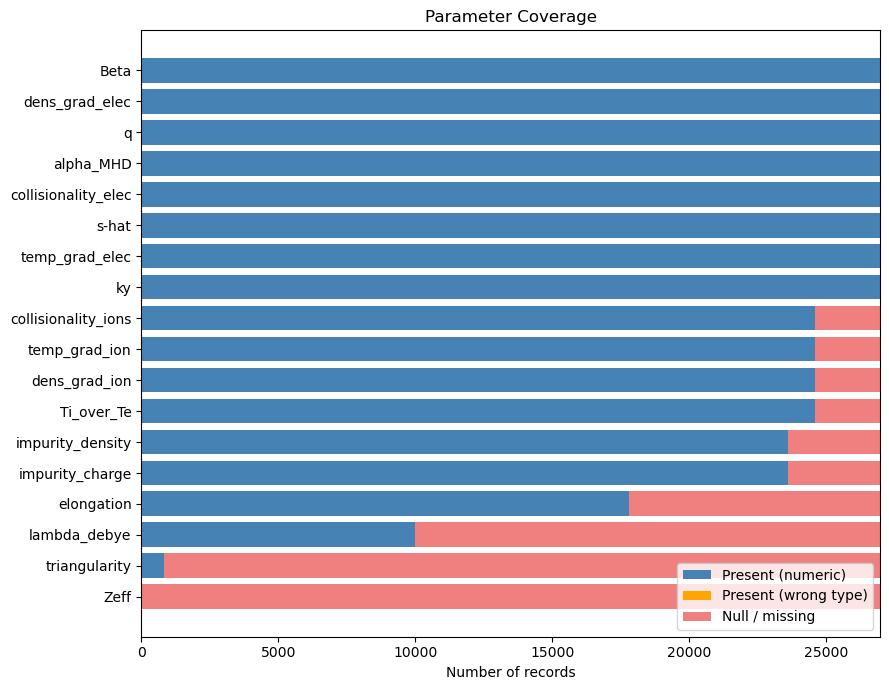

In [7]:
plot_coverage(df)

In [14]:
df = df.dropna(subset=['Ti_over_Te'])

df = df.fillna({'impurity_density': 0,
                'impurity_charge': 0,
                'dens_grad_ion': 0,
                'temp_grad_ion': 0,})

# df = df.drop(columns=['triangularity',
#                  'elongation',
#                  'Zeff',
#                  'lambda_debye',
#                  'collisionality_ions'])

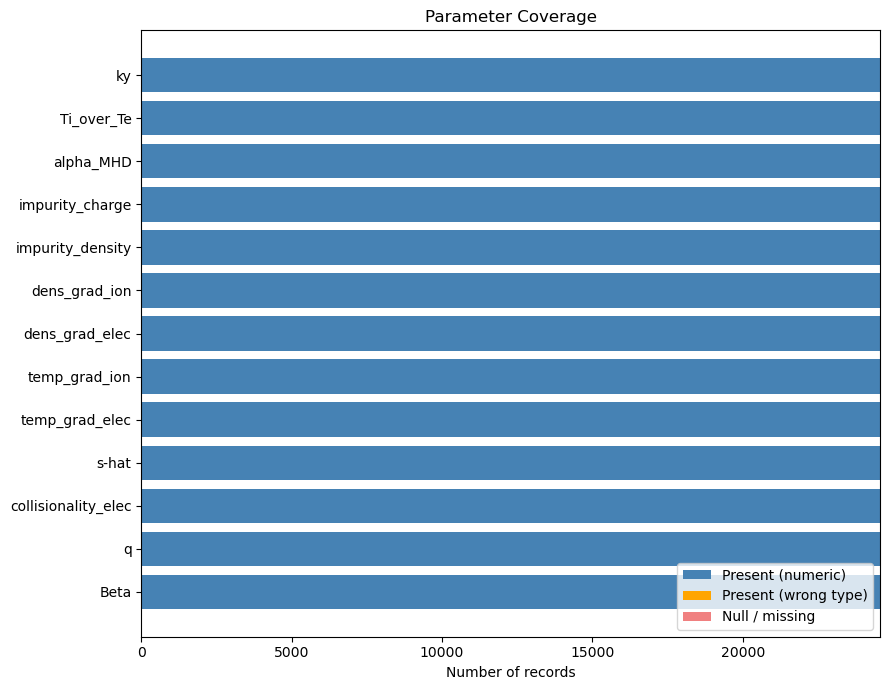

In [15]:
plot_coverage(df)

In [18]:
# df['dens_grad_ion'].value_counts(dropna=False)
# # df['dens_grad_ion'].value_counts()
# # df['impurity_density'].value_counts()

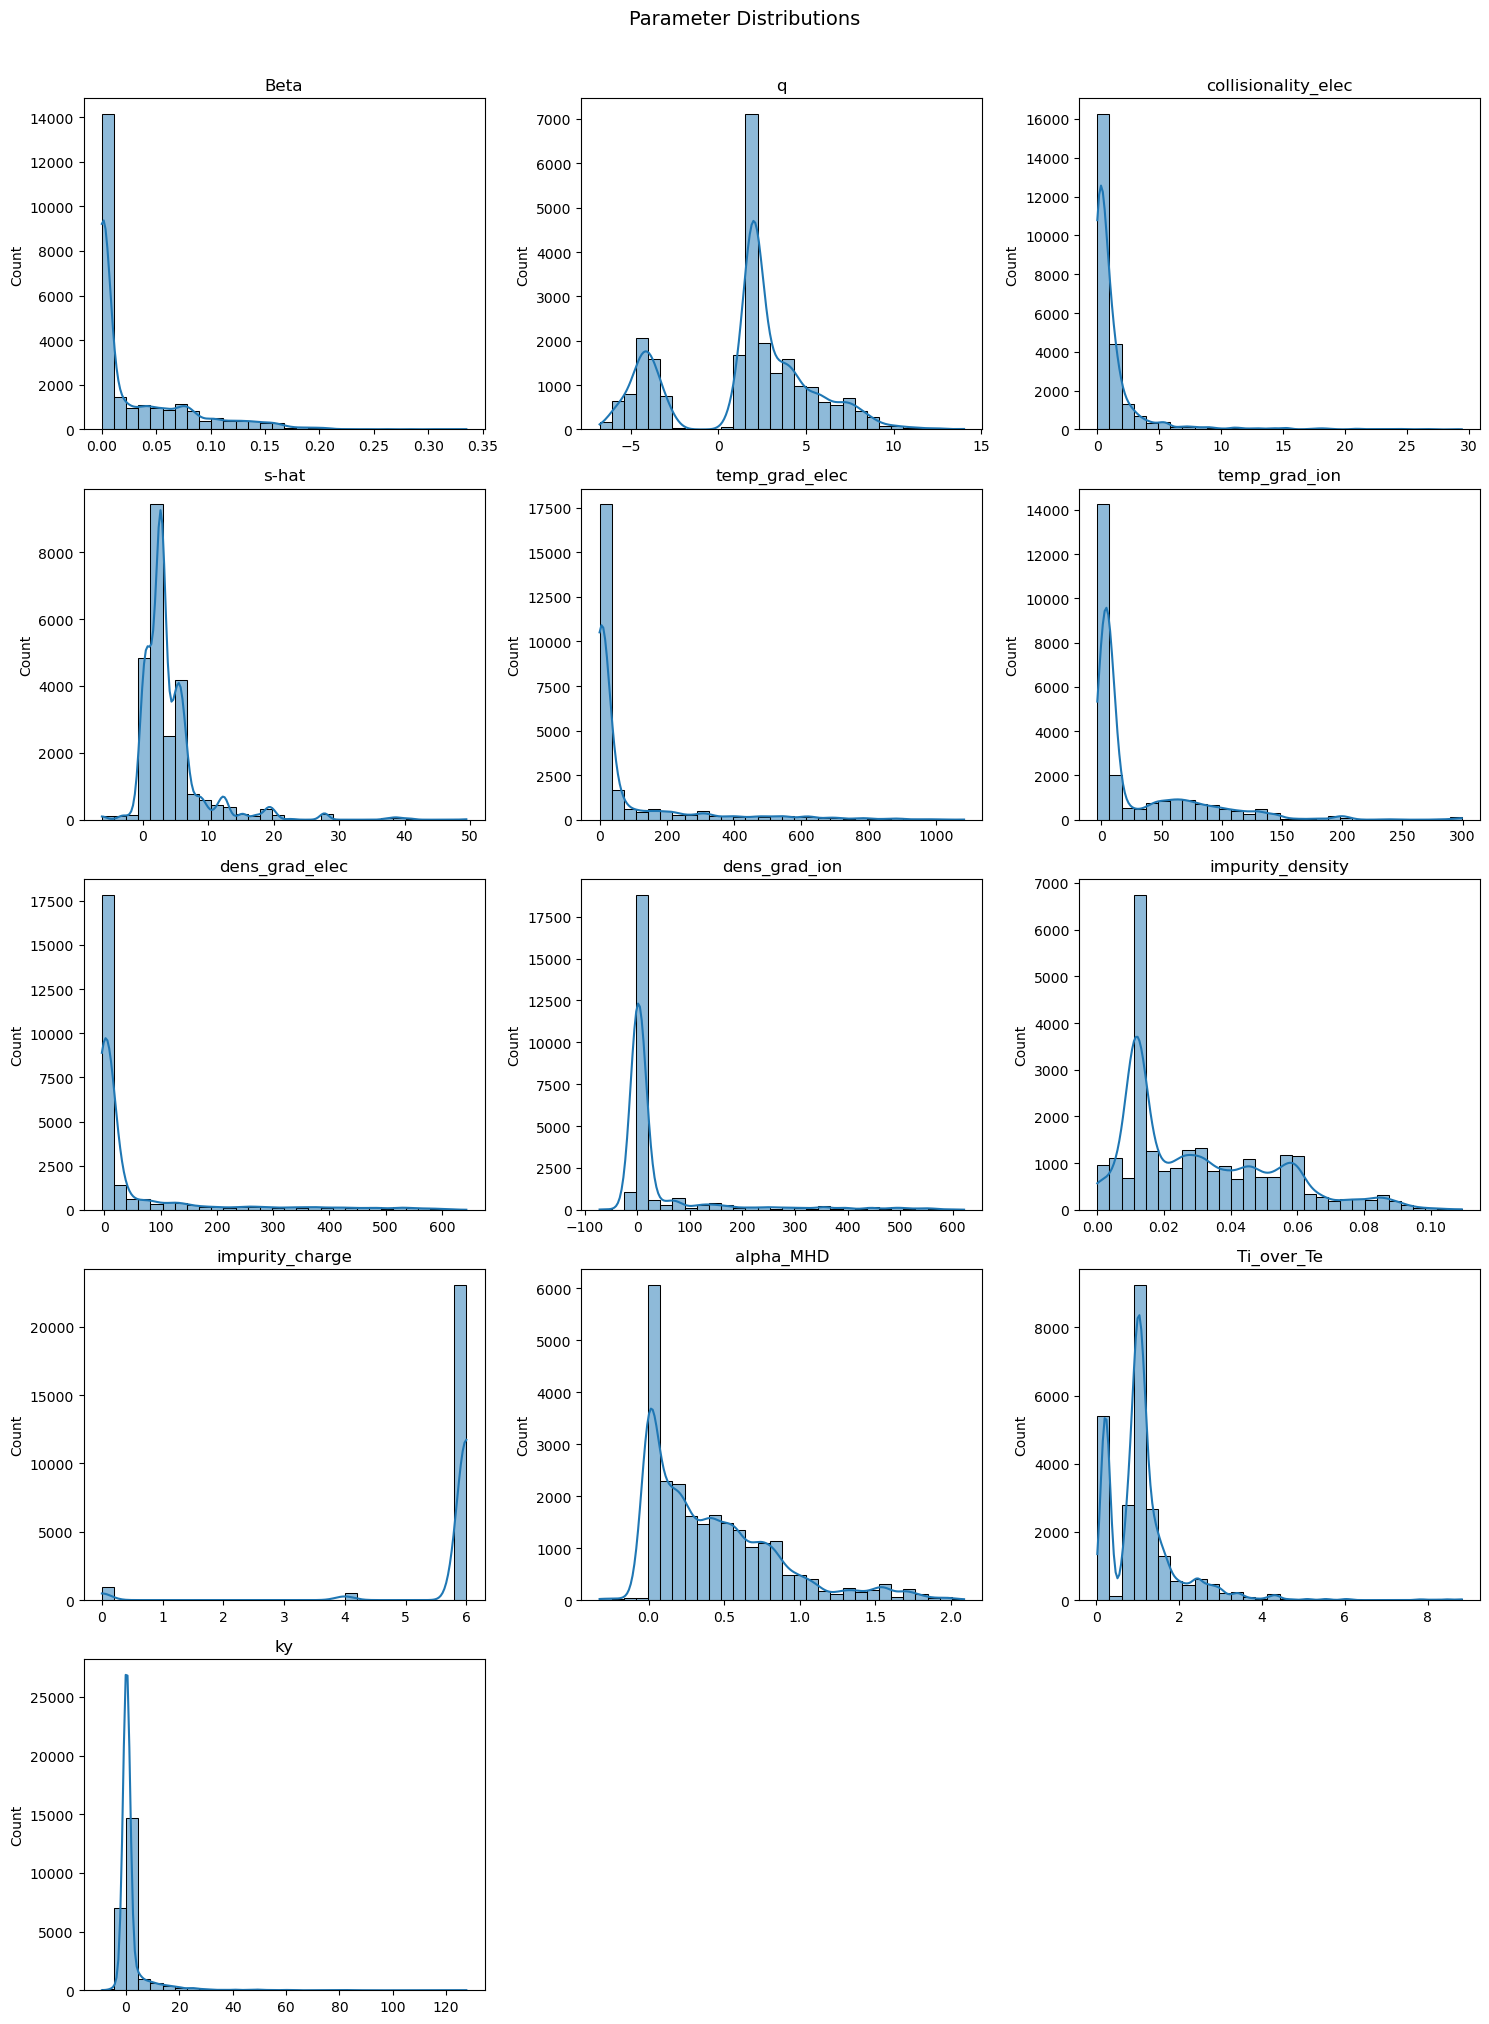

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = df.select_dtypes(include='number').columns.tolist()
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Parameter Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()